# SOP Retriever Evaluation

The benchmark uses annotated queries (`questions.csv`) with known source files, pages, and evidence snippets. Evaluation is performed via `evaluate_retriever.py`.

### Metrics

Retrieval quality is measured at two levels:
* **file_hit** – correct SOP file appears in top-k results
* **evidence_hit** – retrieved content contains a gold evidence snippet


---

## Notebook Structure

This notebook includes four parts:
* **Part 1:** Recall evaluation
* **Part 2:** MRR evaluation


In [ ]:
from pathlib import Path
import json
import statistics
import sys
import time
import unicodedata
from collections import Counter, defaultdict
from datetime import datetime
from typing import Any, Dict, Iterable, List, Optional

import pandas as pd
from IPython.display import display
from pypdf import PdfReader
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from SOP_utils import *

# Path to the CSV file containing evaluation questions
QUESTIONS_PATH: Path = Path("questions.csv")  # change as needed

# Directory containing the source SOP PDFs.
# Set to None to auto-detect using SOP_DATA_DIR / project defaults.
PDF_DIR: Path | None = None

# ---- project root on sys.path ----
CURRENT_DIR = Path(".").resolve()
PROJECT_ROOT = CURRENT_DIR.parent.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from backend.sop_rag.config import SOP_DATA_DIR          # noqa: E402
from backend.sop_rag.sop_retriever import SOPRetriever   # noqa: E402

print(f"Project root  : {PROJECT_ROOT}")
print(f"SOP_DATA_DIR  : {SOP_DATA_DIR}")


Project root  : /Users/dinhu955/Desktop/RepurAgent/repuragent-web
SOP_DATA_DIR  : persistence/data/SOP


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Nature-style global settings
COLORS = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB']

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 15,
    'axes.titlesize': 8,
    'axes.labelsize': 7,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 15,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.6,
    'ytick.minor.width': 0.6,
    'lines.linewidth': 1.0,
    'patch.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
sns.set_theme(style="ticks")


# Prepare data

In [3]:
questions = load_questions(QUESTIONS_PATH)
pdf_dir   = resolve_pdf_dir(PDF_DIR)
pdf_map   = resolve_pdf_map(pdf_dir)

# Part 1: Recall evaluation

Evaluate the top 4 retrieved chunks to determine whether the retriever returns relevant chunks containing evidence snippets.

In [4]:
retriever        = SOPRetriever()
question_results = evaluate_questions(retriever, questions, k=4)

/Users/dinhu955/Desktop/RepurAgent/repuragent-web/backend/sop_rag/sop_retriever.py:65: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  vectorstore = Chroma(
INFO:chromadb.telemetry.product.posthog:Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Loaded vector store with 83 documents
MultiVectorRetriever created with vectorstore and docstore
Docstore contains 83 documents


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
I

In [5]:
recall_file = recall(question_results['file_match_rank'])
recall_evidence = recall(question_results['evidence_match_rank'])

print(f'Recall@4 at file-level: {recall_file}')
print(f'Recall@4 at evidence-level: {recall_evidence}')

Recall@4 at file-level: 0.95
Recall@4 at evidence-level: 0.795


/var/folders/y3/3m3209mn1sxcmgxls255b9f40000gn/T/ipykernel_58863/101137787.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


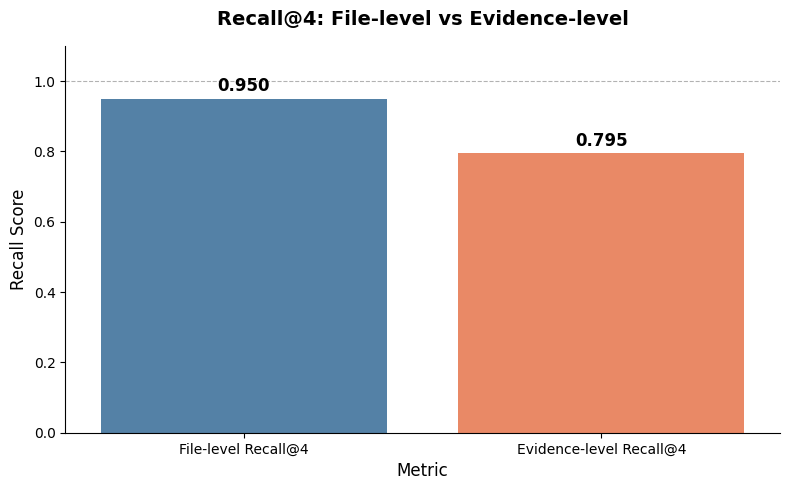

In [6]:
# Prepare data for plotting
labels = ['File-level Recall@4', 'Evidence-level Recall@4']
values = [recall_file, recall_evidence]

# Create the bar plot
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=labels,
    y=values,
    palette=['steelblue', 'coral'],
    ax=ax
)

# Add value labels on top of each bar
for i, v in enumerate(values):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting
ax.set_title('Recall@4: File-level vs Evidence-level', fontsize=14, pad=15)
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Recall Score', fontsize=12)
ax.set_ylim(0, min(1.1, max(values) * 1.2))  # Dynamic y-axis with headroom
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Max (1.0)')

sns.despine()
plt.tight_layout()
plt.show()

In [7]:
question_types_recall = {'query_type': [], 'recall@4_file': [], 'recall@4_evidence': [], 'number':[]}

for type in set(question_results['query_type']):
    question_results_type = question_results[question_results['query_type']==type]
    n = len(question_results_type)

    recall_file = recall(question_results_type['file_match_rank'])
    recall_evidence = recall(question_results_type['evidence_match_rank'])

    question_types_recall['query_type'].append(type)
    question_types_recall['recall@4_file'].append(recall_file)
    question_types_recall['recall@4_evidence'].append(recall_evidence)
    question_types_recall['number'].append(n)

question_types_recall = pd.DataFrame(question_types_recall)
question_types_recall

,query_type,recall@4_file,recall@4_evidence,number
0,quality_control,1.000000,0.866667,15
1,filter_rule,1.000000,1.000000,10
2,equipment_lookup,1.000000,0.666667,15
3,cell_line_lookup,0.857143,0.714286,7
4,toxicity_rule,1.000000,0.666667,9
5,goal_lookup,1.000000,0.875000,16
6,database_lookup,1.000000,1.000000,10
7,procedure_lookup,0.866667,0.800000,15
8,control_lookup,0.933333,0.800000,15
9,safety_lookup,1.000000,0.583333,12


/var/folders/y3/3m3209mn1sxcmgxls255b9f40000gn/T/ipykernel_58863/734166141.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels, fontsize=10, rotation = 50)


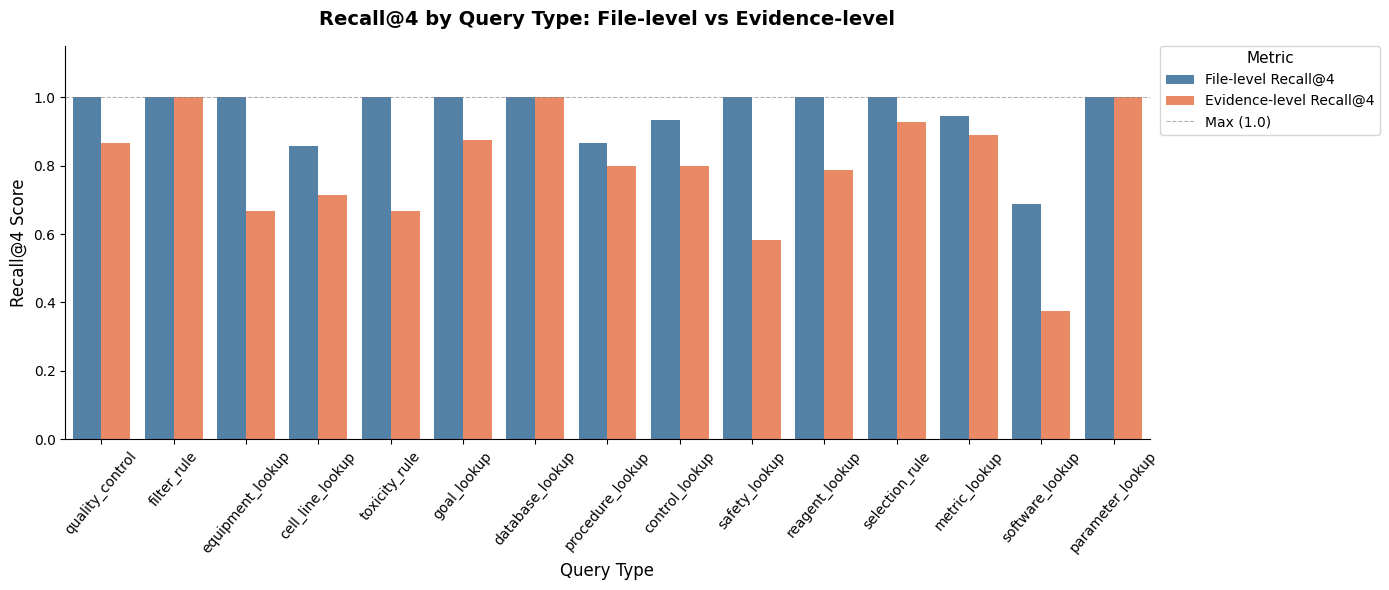

In [8]:
# Melt to long format for grouped bar plot
df_melted = question_types_recall.melt(
    id_vars='query_type',
    value_vars=['recall@4_file', 'recall@4_evidence'],
    var_name='Metric',
    value_name='Score'
)

# Rename for cleaner legend labels
df_melted['Metric'] = df_melted['Metric'].map({
    'recall@4_file': 'File-level Recall@4',
    'recall@4_evidence': 'Evidence-level Recall@4'
})

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=df_melted,
    x='query_type',
    y='Score',
    hue='Metric',
    palette=['steelblue', 'coral'],
    ax=ax
)

# Add sample size annotations below x-axis labels
query_order = df_melted['query_type'].unique()
n_map = question_types_recall.set_index('query_type')['number'].to_dict()
xtick_labels = [f"{qt}" for qt in query_order]
ax.set_xticklabels(xtick_labels, fontsize=10, rotation = 50)

# Formatting
ax.set_title('Recall@4 by Query Type: File-level vs Evidence-level', fontsize=14, pad=15)
ax.set_xlabel('Query Type', fontsize=12)
ax.set_ylabel('Recall@4 Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Max (1.0)')
ax.legend(title='Metric', fontsize=10, title_fontsize=11, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

sns.despine()
plt.tight_layout()
plt.show()

# Part 2: Mean Reciprocal Rank (MRR) evaluation

Evaluate the all retrieved chunks and their ranks to determine whether the retriever prioritises relevant chunks containing evidence snippets.

In [9]:
retriever        = SOPRetriever()
question_results = evaluate_questions(retriever, questions, k=83)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


Loaded vector store with 83 documents
MultiVectorRetriever created with vectorstore and docstore
Docstore contains 83 documents


INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://api.openai.com/v1/embedding

In [10]:
mrr_file = mrr(question_results['file_match_rank'])
mrr_evidence = mrr(question_results['evidence_match_rank'])

print(f'MRR at file-level: {mrr_file}')
print(f'MRR at evidence-level: {mrr_evidence}')

MRR at file-level: 0.8828209325396825
MRR at evidence-level: 0.6066928314740815


/var/folders/y3/3m3209mn1sxcmgxls255b9f40000gn/T/ipykernel_58863/1752070511.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


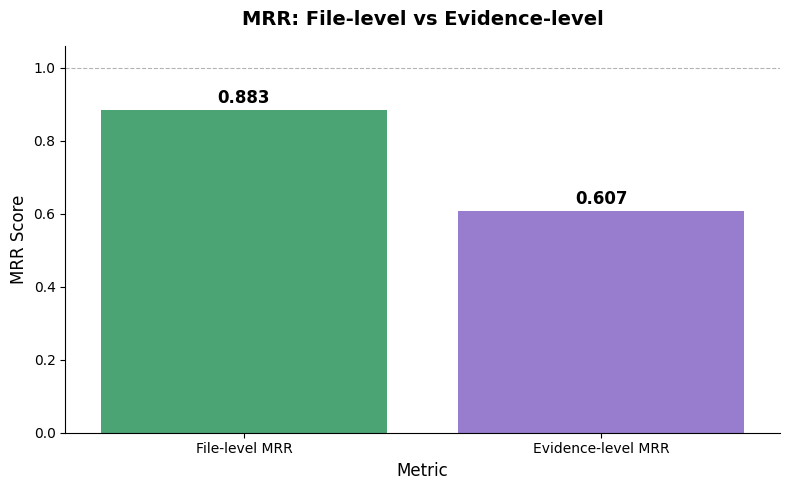

In [11]:
# Prepare data for plotting
labels = ['File-level MRR', 'Evidence-level MRR']
values = [mrr_file, mrr_evidence]

# Create the bar plot
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=labels,
    y=values,
    palette=['mediumseagreen', 'mediumpurple'],
    ax=ax
)

# Add value labels on top of each bar
for i, v in enumerate(values):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting
ax.set_title('MRR: File-level vs Evidence-level', fontsize=14, pad=15)
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('MRR Score', fontsize=12)
ax.set_ylim(0, min(1.1, max(values) * 1.2))
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Max (1.0)')

sns.despine()
plt.tight_layout()
plt.show()

In [12]:
question_types_mrr = {'query_type': [], 'mrr_file': [], 'mrr_evidence': [], 'number':[]}

for type in set(question_results['query_type']):
    question_results_type = question_results[question_results['query_type']==type]
    n = len(question_results_type)

    mrr_file = mrr(question_results_type['file_match_rank'])
    mrr_evidence = mrr(question_results_type['evidence_match_rank'])

    question_types_mrr['query_type'].append(type)
    question_types_mrr['mrr_file'].append(mrr_file)
    question_types_mrr['mrr_evidence'].append(mrr_evidence)
    question_types_mrr['number'].append(n)

question_types_mrr = pd.DataFrame(question_types_mrr)
question_types_mrr

,query_type,mrr_file,mrr_evidence,number
0,quality_control,0.900000,0.787302,15
1,filter_rule,1.000000,0.725000,10
2,equipment_lookup,0.872222,0.475000,15
3,cell_line_lookup,0.877551,0.480159,7
4,toxicity_rule,0.925926,0.600000,9
5,goal_lookup,0.906250,0.654762,16
6,database_lookup,1.000000,0.500000,10
7,procedure_lookup,0.818889,0.584524,15
8,control_lookup,0.874074,0.701852,15
9,safety_lookup,1.000000,0.559188,12


/var/folders/y3/3m3209mn1sxcmgxls255b9f40000gn/T/ipykernel_58863/2416257987.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xtick_labels, fontsize=10, rotation = 50)


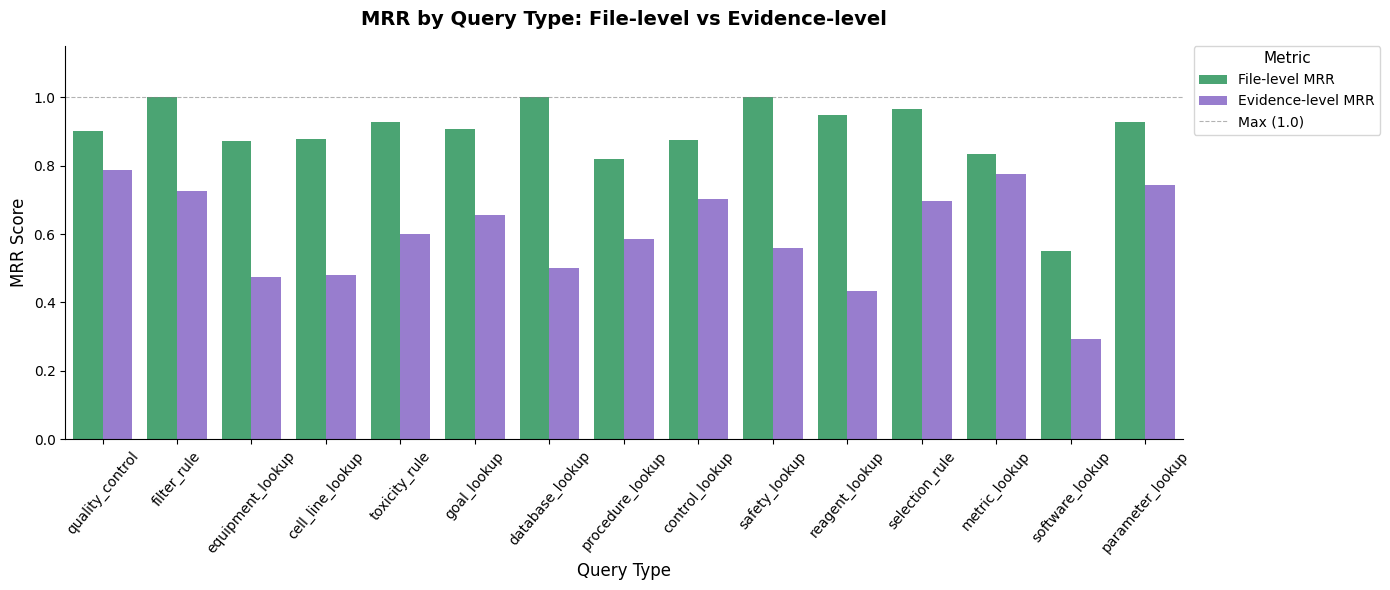

In [13]:
# Melt to long format for grouped bar plot
df_melted = question_types_mrr.melt(
    id_vars='query_type',
    value_vars=['mrr_file', 'mrr_evidence'],
    var_name='Metric',
    value_name='Score'
)

# Rename for cleaner legend labels
df_melted['Metric'] = df_melted['Metric'].map({
    'mrr_file': 'File-level MRR',
    'mrr_evidence': 'Evidence-level MRR'
})

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=df_melted,
    x='query_type',
    y='Score',
    hue='Metric',
    palette=['mediumseagreen', 'mediumpurple'],
    ax=ax
)

# Add sample size annotations below x-axis labels
query_order = df_melted['query_type'].unique()
n_map = question_types_recall.set_index('query_type')['number'].to_dict()
xtick_labels = [f"{qt}" for qt in query_order]
ax.set_xticklabels(xtick_labels, fontsize=10, rotation = 50)

# Formatting
ax.set_title('MRR by Query Type: File-level vs Evidence-level', fontsize=14, pad=15)
ax.set_xlabel('Query Type', fontsize=12)
ax.set_ylabel('MRR Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Max (1.0)')
ax.legend(title='Metric', fontsize=10, title_fontsize=11, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

sns.despine()
plt.tight_layout()
plt.show()